# 03b — Markowitz Pre-Pandemia: Entrenamiento 2015-2019 / Evaluación 2020+

> **Proyecto**: Optimización de Portafolios con ML — Tecnológico de Monterrey, AD2026  
> **Etapa**: 03b / 09 — Markowitz sin pandemia en muestra  
> **Módulo**: `src/models/markowitz_benchmark.py`

## Motivación

El notebook **03** utiliza IS = 2015–2022, lo que **incluye el choque pandémico de 2020**  
dentro del período de estimación de parámetros. Esto contamina la covarianza estimada  
con un régimen de volatilidad excepcional.

Este notebook repite el análisis con:

| Período | Rango | Uso |
|---------|-------|-----|
| **In-Sample (IS)**      | 2015-01-02 → 2019-12-31 | Estimación de parámetros (sin pandemia) |
| **Out-of-Sample (OOS)** | 2020-01-01 → 2025-03-13 | Evaluación real: pandemia + recuperación + rally 2021-2023 |

### Preguntas de investigación

1. ¿Cómo se comportan los portafolios Markowitz clásicos ante un **choque de régimen** no visto durante la estimación?
2. ¿El modelo de mínima varianza (GMV) protege mejor que el de máximo Sharpe (MSR) ante la pandemia?
3. ¿Qué tan rápido se recuperan los portafolios vs SPY en el período 2021-2025?
4. ¿Qué limitaciones del modelo clásico justifican el uso de ML y CVaR?


---
## 0. Configuración

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

from src.models.markowitz_benchmark import (
    MarkowitzOptimizer,
    full_metrics,
    compute_portfolio_returns,
    ALL_TICKERS,
    REPRES,
    SECTOR_LOOKUP,
    BENCHMARK,
    RF_ANNUAL,
    TRADING_DAYS,
    max_drawdown,
    annualized_return,
    annualized_vol,
    sharpe_ratio,
    cvar_historical,
)

# ── Estética ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

PALETTE = {
    'Information Technology': '#4C9BE8',
    'Consumer Staples':       '#2ECC71',
    'Health Care':            '#E74C3C',
    'Consumer Discretionary': '#F39C12',
    'SPY / Benchmark':        '#95A5A6',
}
P_MSR = '#8E44AD'
P_GMV = '#1ABC9C'
P_EW  = '#E67E22'
P_SPY = '#95A5A6'

# ── Rutas ─────────────────────────────────────────────────────────────────────
CSV_PATH    = '../data/datos.csv'
OUTPUT_DIR  = '../data/processed/markowitz_prepandemic'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Parámetros temporales ─────────────────────────────────────────────────────
FECHA_INICIO   = '2015-01-02'
TRAIN_END      = '2019-12-31'
OOS_START      = '2020-01-01'
PANDEMIC_START = '2020-02-19'
PANDEMIC_END   = '2020-04-07'
RECOVERY_END   = '2020-08-18'

print('Configuracion lista')
print(f'  Universo: {len(ALL_TICKERS)} activos de 4 sectores GICS')
print(f'  IS (pre-pandemia) : {FECHA_INICIO} -> {TRAIN_END}')
print(f'  OOS (con pandemia): {OOS_START} -> 2025-03-13')

Configuracion lista
  Universo: 40 activos de 4 sectores GICS
  IS (pre-pandemia) : 2015-01-02 -> 2019-12-31
  OOS (con pandemia): 2020-01-01 -> 2025-03-13


---
## 1. Carga de Datos y División Temporal

In [2]:
df_raw = pd.read_csv(CSV_PATH)
business_days = pd.bdate_range(start=pd.Timestamp(FECHA_INICIO), periods=len(df_raw))
df_raw.index = business_days
df_raw.index.name = 'Date'
df_raw = df_raw.drop(columns=['promedio'], errors='ignore')

use_tickers = ALL_TICKERS + [BENCHMARK]
available   = [t for t in use_tickers if t in df_raw.columns]
prices      = df_raw[available].copy()

print(f'Precio cargado: {prices.shape[0]} dias x {prices.shape[1]} activos')
print(f'Periodo total : {prices.index[0].date()} -> {prices.index[-1].date()}')

log_ret = np.log(prices / prices.shift(1)).dropna(how='all')

ret_is  = log_ret[log_ret.index <= TRAIN_END]
ret_oos = log_ret[log_ret.index >= OOS_START]

ret_pandemic  = ret_oos[ret_oos.index <= '2020-12-31']
ret_recovery  = ret_oos[(ret_oos.index >= '2021-01-01') & (ret_oos.index <= '2022-12-31')]
ret_post      = ret_oos[ret_oos.index >= '2023-01-01']

print(f'IS  : {ret_is.index[0].date()} -> {ret_is.index[-1].date()} ({len(ret_is):,} dias)')
print(f'OOS : {ret_oos.index[0].date()} -> {ret_oos.index[-1].date()} ({len(ret_oos):,} dias)')
print(f'  Pandemia 2020      : {len(ret_pandemic):,} dias')
print(f'  Recuperacion 21-22 : {len(ret_recovery):,} dias')
print(f'  Post-2023          : {len(ret_post):,} dias')

Precio cargado: 2660 dias x 41 activos
Periodo total : 2015-01-02 -> 2025-03-13
IS  : 2015-01-05 -> 2019-12-31 (1,302 dias)
OOS : 2020-01-01 -> 2025-03-13 (1,357 dias)
  Pandemia 2020      : 262 dias
  Recuperacion 21-22 : 521 dias
  Post-2023          : 574 dias


---
## 2. Optimización In-Sample (2015-2019)

In [3]:
opt = MarkowitzOptimizer(
    prices       = prices,
    tickers      = ALL_TICKERS,
    train_end    = TRAIN_END,
    weight_bounds= (0.0, 0.25),
    shrinkage    = True,
    rf           = RF_ANNUAL,
)

print('Calculando portafolios base (IS 2015-2019)...')
msr = opt.max_sharpe()
gmv = opt.min_variance()
ew  = opt.equal_weight()

print(f'\n  {msr}')
print(f'  {gmv}')
print(f'  {ew}')

print('\nCalculando frontera eficiente...')
frontier = opt.efficient_frontier(n_points=120)
print(f'Frontera: {len(frontier)} puntos')

Calculando portafolios base (IS 2015-2019)...

  PortfolioResult('Max Sharpe (MSR)' | ret=31.91%, vol=19.78%, sharpe=1.348)
  PortfolioResult('Min Varianza (GMV)' | ret=9.72%, vol=11.53%, sharpe=0.388)
  PortfolioResult('Igual Ponderación (EW)' | ret=15.20%, vol=14.39%, sharpe=0.692)

Calculando frontera eficiente...
Frontera: 86 puntos


In [4]:
metrics_is, metrics_oos = opt.compare_all()

print('METRICAS IN-SAMPLE (estimadas 2015-2019)')
print('=' * 60)
print(metrics_is.to_string())

print('\nMETRICAS OUT-OF-SAMPLE (2020-2025)')
print('=' * 60)
print(metrics_oos.to_string())

METRICAS IN-SAMPLE (estimadas 2015-2019)
                        ret_annual  vol_annual    sharpe
Portafolio                                              
Max Sharpe (MSR)          0.319148    0.197751  1.348404
Min Varianza (GMV)        0.097208    0.115291  0.387782
Igual Ponderación (EW)    0.152021    0.143918  0.691511
SPY (Benchmark)           0.090700    0.140600  0.271700

METRICAS OUT-OF-SAMPLE (2020-2025)
                        ret_annual  vol_annual  sharpe  sortino  max_drawdown   cvar_95    beta  information_ratio  calmar
Portafolio                                                                                                                
Max Sharpe (MSR)            0.2359      0.2631  0.6969   0.9080       -0.3741 -0.038290  1.0933             0.6364  0.6305
Min Varianza (GMV)          0.0783      0.1635  0.1576   0.1916       -0.2468 -0.023795  0.5907            -0.5637  0.3171
Igual Ponderación (EW)      0.1469      0.1983  0.4761   0.5740       -0.2542 -0.029971  

---
## 3. Frontera Eficiente Pre-Pandemia

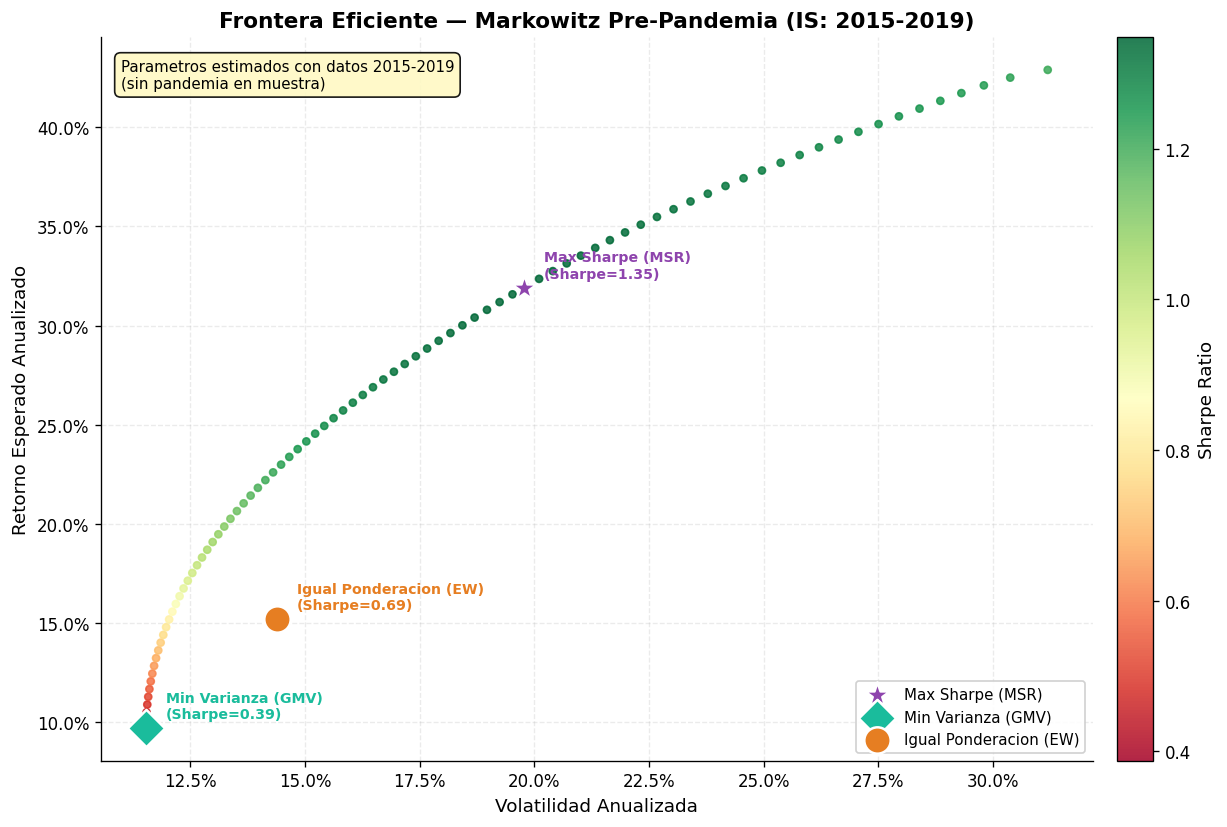

Grafico guardado


In [5]:
fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(
    frontier['vol'], frontier['ret'],
    c=frontier['sharpe'], cmap='RdYlGn', s=18, zorder=3, alpha=0.85
)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio', pad=0.02)

for res, color, marker, label in [
    (msr, P_MSR, '*', 'Max Sharpe (MSR)'),
    (gmv, P_GMV, 'D', 'Min Varianza (GMV)'),
    (ew,  P_EW,  'o', 'Igual Ponderacion (EW)'),
]:
    ax.scatter(
        res.vol_annual, res.ret_annual,
        c=color, s=250, marker=marker, zorder=6,
        edgecolors='white', linewidths=1.5, label=label
    )
    ax.annotate(
        f'{label}\n(Sharpe={res.sharpe:.2f})',
        xy=(res.vol_annual, res.ret_annual),
        xytext=(12, 6), textcoords='offset points',
        fontsize=8.5, color=color, fontweight='bold'
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('Volatilidad Anualizada')
ax.set_ylabel('Retorno Esperado Anualizado')
ax.set_title('Frontera Eficiente — Markowitz Pre-Pandemia (IS: 2015-2019)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--')

ax.text(
    0.02, 0.97,
    'Parametros estimados con datos 2015-2019\n(sin pandemia en muestra)',
    transform=ax.transAxes, fontsize=9, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4', alpha=0.9)
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/frontera_eficiente_prepandemia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado')

---
## 4. Distribución de Pesos por Portafolio

In [6]:
wt = opt.weights_table()
print('Tabla de pesos (portafolios base):')
print(wt.round(4).to_string())

Tabla de pesos (portafolios base):
        Max Sharpe (MSR)  Min Varianza (GMV)  Igual Ponderación (EW)                  Sector
Ticker                                                                                      
TJX               0.0000              0.0552                   0.025  Consumer Discretionary
RCL               0.0000              0.0000                   0.025  Consumer Discretionary
BKNG              0.0000              0.0235                   0.025  Consumer Discretionary
SBUX              0.0000              0.0040                   0.025  Consumer Discretionary
NKE               0.0000              0.0000                   0.025  Consumer Discretionary
MCD               0.2500              0.1353                   0.025  Consumer Discretionary
HD                0.0000              0.0000                   0.025  Consumer Discretionary
TSLA              0.0000              0.0000                   0.025  Consumer Discretionary
AMZN              0.2500           

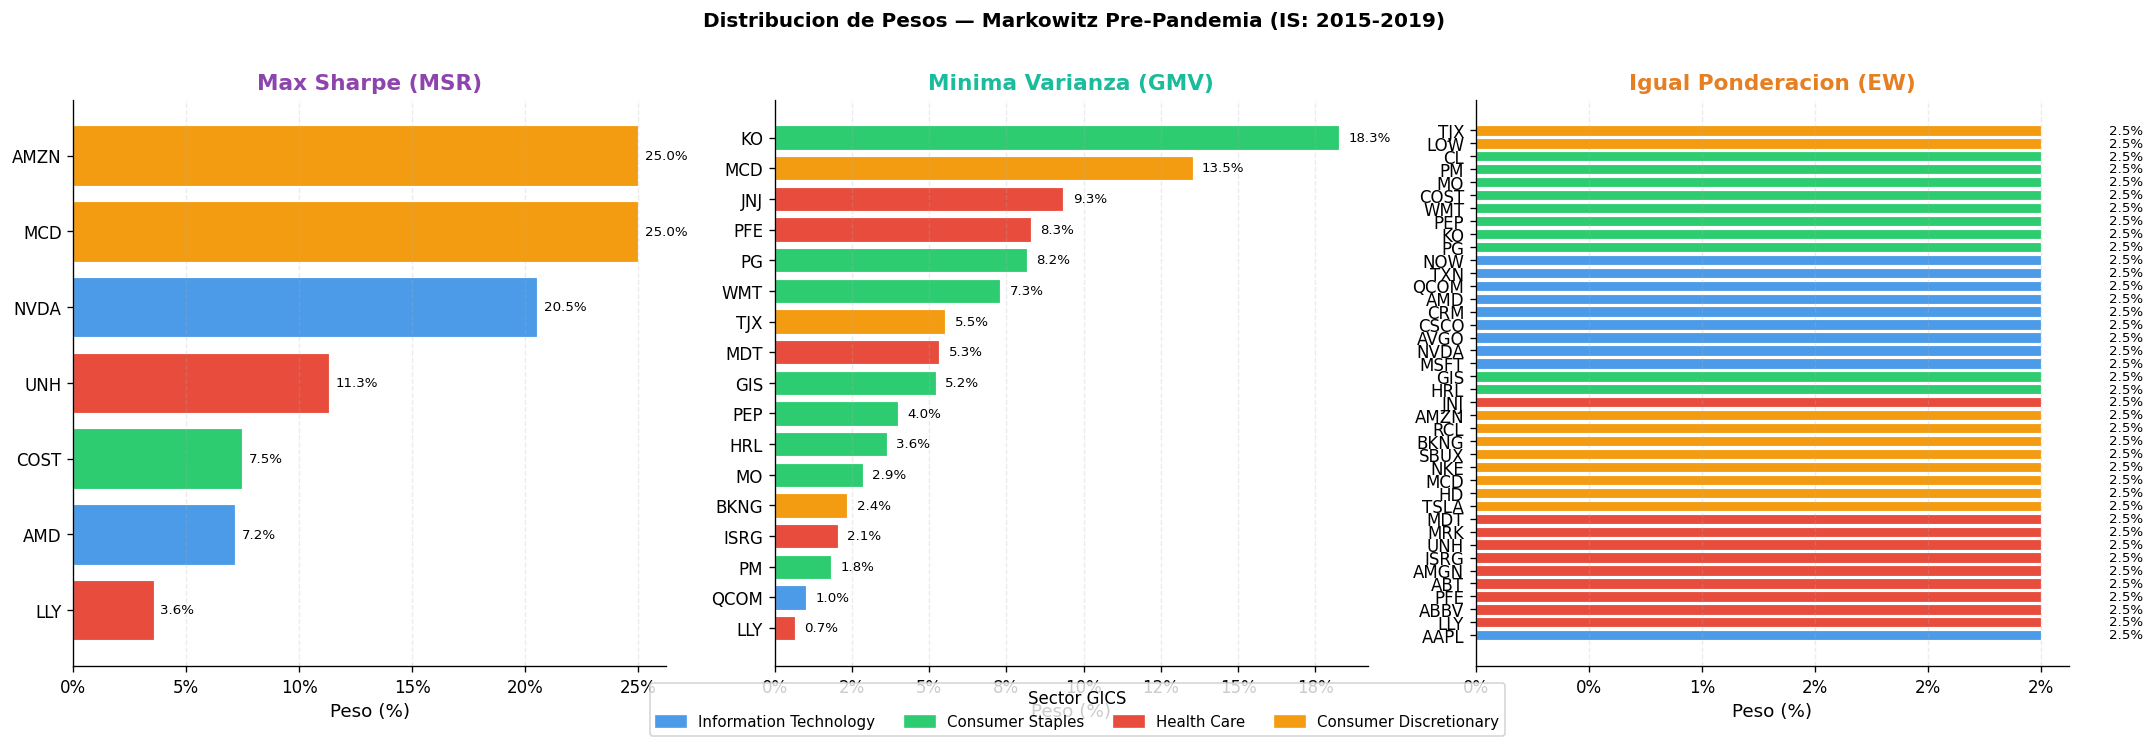

Grafico guardado


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

portafolios_plot = [
    (msr, P_MSR, 'Max Sharpe (MSR)'),
    (gmv, P_GMV, 'Minima Varianza (GMV)'),
    (ew,  P_EW,  'Igual Ponderacion (EW)'),
]

for ax, (res, color, title) in zip(axes, portafolios_plot):
    w = res.weights[res.weights > 0.005].sort_values(ascending=True)
    bar_colors = [PALETTE.get(SECTOR_LOOKUP.get(t, ''), '#aaa') for t in w.index]
    ax.barh(w.index, w.values * 100, color=bar_colors, edgecolor='white', linewidth=0.7)
    ax.set_xlabel('Peso (%)')
    ax.set_title(title, fontweight='bold', color=color)
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    for i, (ticker, val) in enumerate(w.items()):
        ax.text(val * 100 + 0.3, i, f'{val:.1%}', va='center', fontsize=8)

legend_patches = [mpatches.Patch(color=c, label=s) for s, c in PALETTE.items() if s != 'SPY / Benchmark']
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9, title='Sector GICS')

plt.suptitle('Distribucion de Pesos — Markowitz Pre-Pandemia (IS: 2015-2019)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pesos_portafolios_prepandemia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado')

---
## 5. Desempeño OOS: 2020 en Adelante

In [8]:
activos_oos = [t for t in ALL_TICKERS if t in ret_oos.columns]

r_msr = compute_portfolio_returns(msr.weights, ret_oos[activos_oos])
r_gmv = compute_portfolio_returns(gmv.weights, ret_oos[activos_oos])
r_ew  = compute_portfolio_returns(ew.weights,  ret_oos[activos_oos])
r_spy = ret_oos[BENCHMARK] if BENCHMARK in ret_oos.columns else None

nav_msr = (1 + r_msr).cumprod() * 100
nav_gmv = (1 + r_gmv).cumprod() * 100
nav_ew  = (1 + r_ew ).cumprod() * 100
nav_spy = (1 + r_spy).cumprod() * 100 if r_spy is not None else None

print('NAV final (base 100):')
print(f'  MSR: {nav_msr.iloc[-1]:.1f}')
print(f'  GMV: {nav_gmv.iloc[-1]:.1f}')
print(f'  EW : {nav_ew.iloc[-1]:.1f}')
if nav_spy is not None:
    print(f'  SPY: {nav_spy.iloc[-1]:.1f}')

NAV final (base 100):
  MSR: 295.2
  GMV: 141.8
  EW : 198.3
  SPY: 204.2


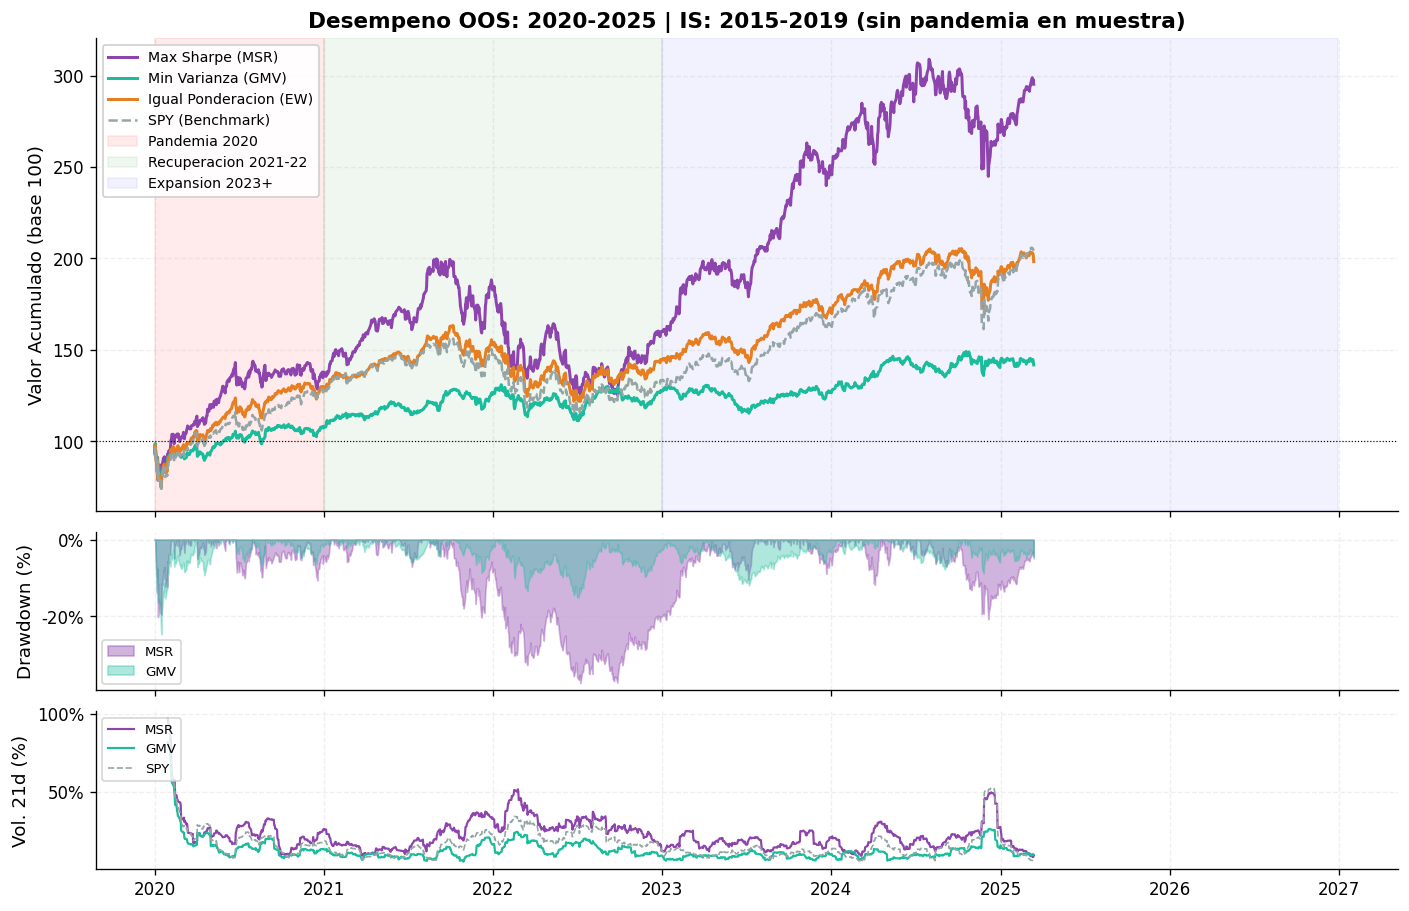

Grafico guardado


In [9]:
fig = plt.figure(figsize=(14, 9))
gs  = GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.08, figure=fig)

ax_nav = fig.add_subplot(gs[0])
ax_dd  = fig.add_subplot(gs[1], sharex=ax_nav)
ax_vol = fig.add_subplot(gs[2], sharex=ax_nav)

# Panel 1: NAV acumulado
ax_nav.plot(nav_msr, color=P_MSR, lw=1.8, label='Max Sharpe (MSR)')
ax_nav.plot(nav_gmv, color=P_GMV, lw=1.8, label='Min Varianza (GMV)')
ax_nav.plot(nav_ew,  color=P_EW,  lw=1.8, label='Igual Ponderacion (EW)')
if nav_spy is not None:
    ax_nav.plot(nav_spy, color=P_SPY, lw=1.5, linestyle='--', label='SPY (Benchmark)')
ax_nav.axhline(100, color='black', lw=0.7, linestyle=':')

ax_nav.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-12-31'),
               alpha=0.08, color='red',    label='Pandemia 2020')
ax_nav.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.06, color='green',  label='Recuperacion 2021-22')
ax_nav.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2026-12-31'),
               alpha=0.05, color='blue',   label='Expansion 2023+')

ax_nav.set_ylabel('Valor Acumulado (base 100)')
ax_nav.set_title('Desempeno OOS: 2020-2025 | IS: 2015-2019 (sin pandemia en muestra)', fontweight='bold')
ax_nav.legend(loc='upper left', fontsize=8.5, framealpha=0.92)
ax_nav.grid(True, alpha=0.2, linestyle='--')

# Panel 2: Drawdown
def rolling_dd(nav_series):
    rolling_max = nav_series.cummax()
    return (nav_series - rolling_max) / rolling_max * 100

ax_dd.fill_between(nav_msr.index, rolling_dd(nav_msr), 0, color=P_MSR, alpha=0.4, label='MSR')
ax_dd.fill_between(nav_gmv.index, rolling_dd(nav_gmv), 0, color=P_GMV, alpha=0.35, label='GMV')
ax_dd.set_ylabel('Drawdown (%)')
ax_dd.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax_dd.legend(loc='lower left', fontsize=8)
ax_dd.grid(True, alpha=0.2, linestyle='--')

# Panel 3: Volatilidad rolling
vol_msr = r_msr.rolling(21).std() * np.sqrt(252) * 100
vol_gmv = r_gmv.rolling(21).std() * np.sqrt(252) * 100
vol_spy_r = r_spy.rolling(21).std() * np.sqrt(252) * 100 if r_spy is not None else None

ax_vol.plot(vol_msr, color=P_MSR, lw=1.3, label='MSR')
ax_vol.plot(vol_gmv, color=P_GMV, lw=1.3, label='GMV')
if vol_spy_r is not None:
    ax_vol.plot(vol_spy_r, color=P_SPY, lw=1.0, linestyle='--', label='SPY')
ax_vol.set_ylabel('Vol. 21d (%)')
ax_vol.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax_vol.legend(loc='upper left', fontsize=8)
ax_vol.grid(True, alpha=0.2, linestyle='--')

ax_vol.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_vol.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax_nav.get_xticklabels(), visible=False)
plt.setp(ax_dd.get_xticklabels(),  visible=False)

plt.savefig(f'{OUTPUT_DIR}/nav_oos_prepandemia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado')

---
## 6. Métricas Granulares por Sub-Período

In [10]:
sub_periods = {
    'Pandemia_2020'       : ret_pandemic,
    'Recuperacion_2021_22': ret_recovery,
    'Expansion_2023_25'   : ret_post,
    'OOS_Total_2020_25'   : ret_oos,
}

results_by_period = {}

for period_name, ret_sub in sub_periods.items():
    spy_sub  = ret_sub[BENCHMARK] if BENCHMARK in ret_sub.columns else pd.Series(dtype=float)
    activos  = [t for t in ALL_TICKERS if t in ret_sub.columns]
    row = {}
    for porto_name, weights in [('MSR', msr.weights), ('GMV', gmv.weights), ('EW', ew.weights)]:
        r = compute_portfolio_returns(weights, ret_sub[activos])
        row[porto_name] = full_metrics(r, spy_sub, label=porto_name)
    if len(spy_sub) > 0:
        row['SPY'] = full_metrics(spy_sub, spy_sub, label='SPY')
    results_by_period[period_name] = pd.DataFrame(row).T

for period, df in results_by_period.items():
    print(f'\n=== {period} ===')
    print(df[['ret_annual','vol_annual','sharpe','sortino','max_drawdown','cvar_95','calmar']].round(4).to_string())


=== Pandemia_2020 ===
     ret_annual  vol_annual  sharpe  sortino  max_drawdown  cvar_95  calmar
MSR      0.3716      0.3521  0.9065   1.0283       -0.2016  -0.0537  1.8436
GMV      0.1138      0.2739  0.2238   0.2549       -0.2468  -0.0444  0.4611
EW       0.3018      0.3138  0.7945   0.8341       -0.2332  -0.0520  1.2941
SPY      0.2878      0.3209  0.7334   0.7852       -0.2388  -0.0525  1.2053

=== Recuperacion_2021_22 ===
     ret_annual  vol_annual  sharpe  sortino  max_drawdown  cvar_95  calmar
MSR      0.1067      0.2677  0.2026   0.2841       -0.3741  -0.0388  0.2853
GMV      0.0892      0.1343  0.2731   0.3742       -0.1502  -0.0193  0.5937
EW       0.0684      0.1814  0.0876   0.1250       -0.2542  -0.0267  0.2691
SPY      0.0401      0.1935 -0.0643  -0.0929       -0.2622  -0.0279  0.1528

=== Expansion_2023_25 ===
     ret_annual  vol_annual  sharpe  sortino  max_drawdown  cvar_95  calmar
MSR      0.2911      0.2056  1.1610   1.7229       -0.2072  -0.0283  1.4051
GMV     

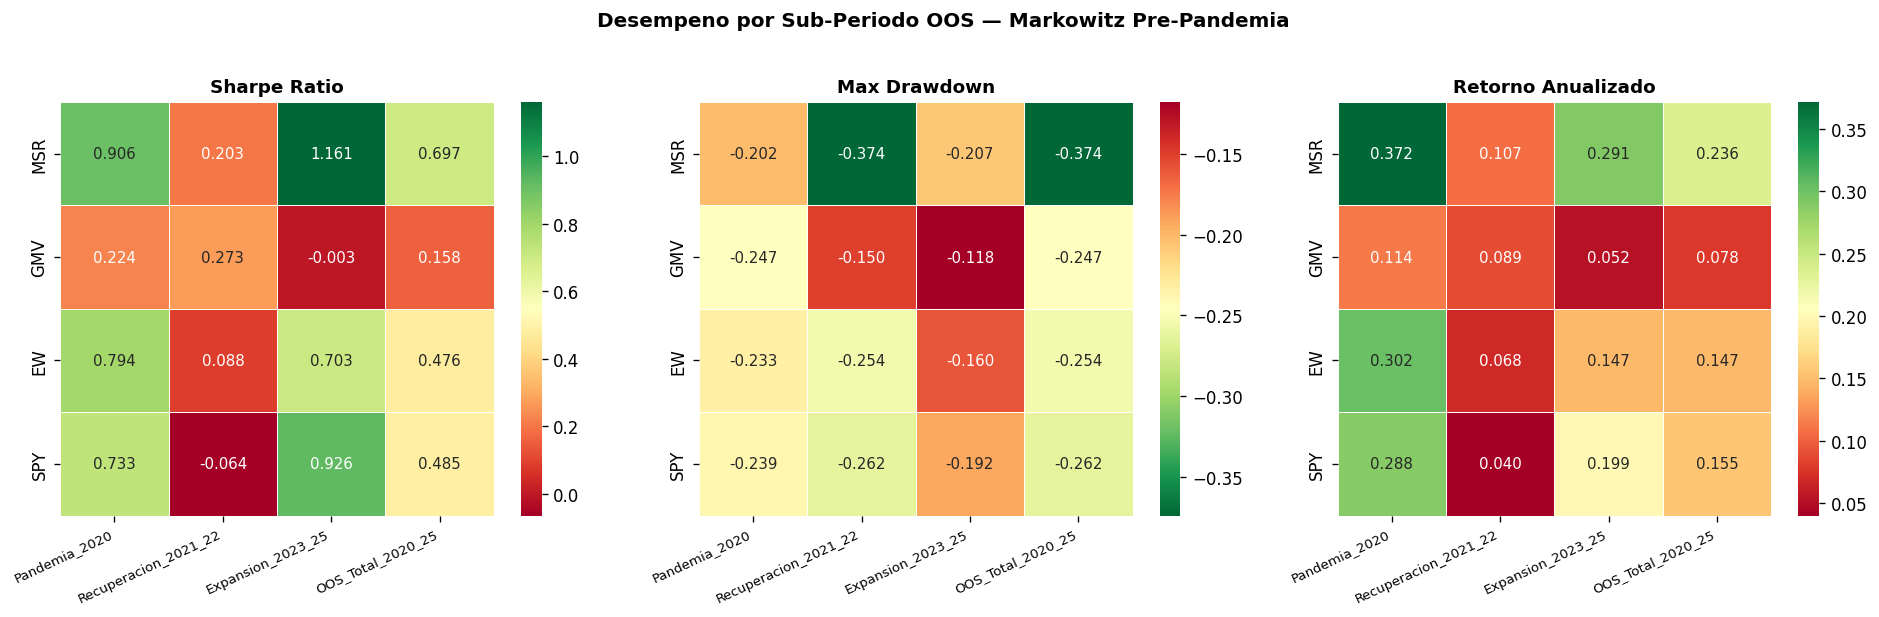

Grafico guardado


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_display = [
    ('sharpe',       'Sharpe Ratio',      'RdYlGn'),
    ('max_drawdown', 'Max Drawdown',       'RdYlGn_r'),
    ('ret_annual',   'Retorno Anualizado', 'RdYlGn'),
]

for ax, (metric, title, cmap) in zip(axes, metrics_display):
    mat = {period: df[metric] for period, df in results_by_period.items() if metric in df.columns}
    mat_df = pd.DataFrame(mat)
    sns.heatmap(
        mat_df, annot=True, fmt='.3f', cmap=cmap,
        ax=ax, linewidths=0.5, cbar=True,
        annot_kws={'size': 9}
    )
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)

plt.suptitle('Desempeno por Sub-Periodo OOS — Markowitz Pre-Pandemia', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/heatmap_subperiodos_prepandemia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado')

---
## 7. Zoom: Crash COVID (Ene–Sep 2020)

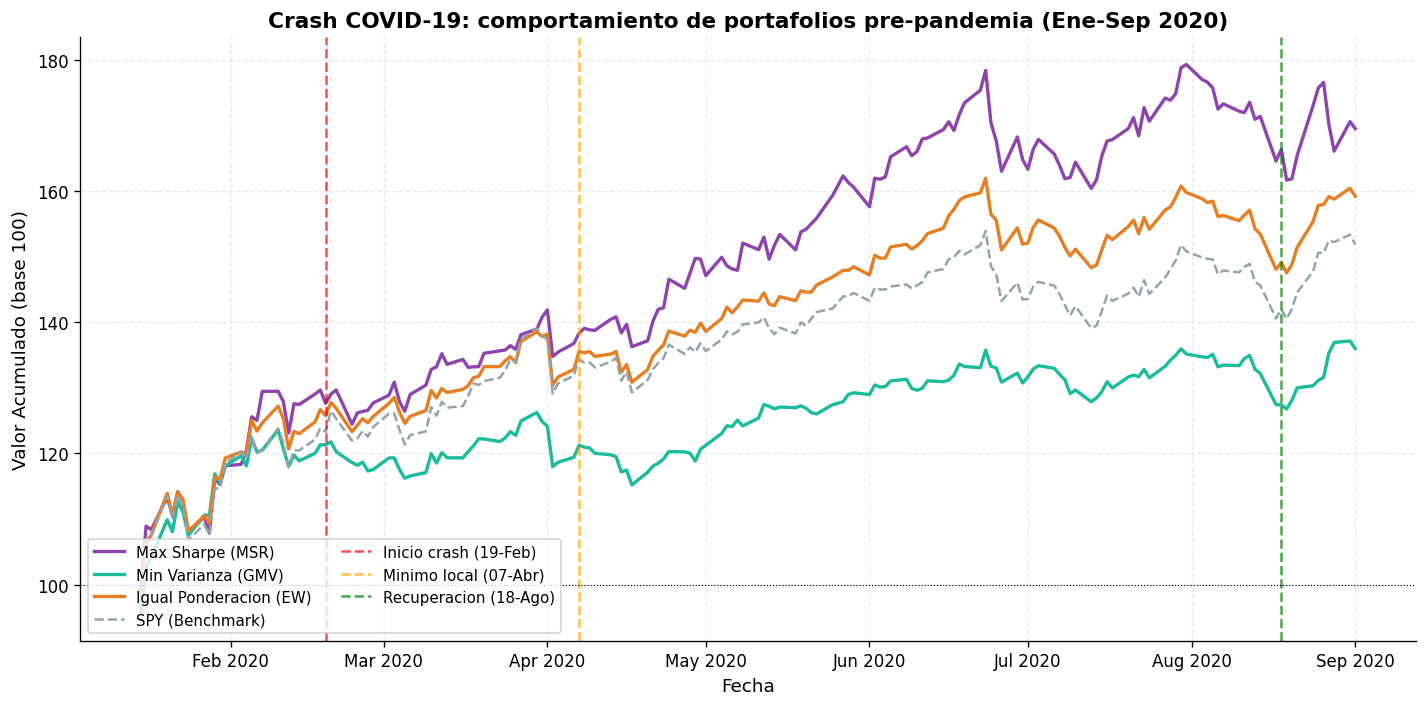


Metricas durante el crash COVID (Ene-Sep 2020):
    Max Drawdown Retorno Total Vol Anualiz. CVaR 95%
MSR      -10.08%        69.49%       31.51%  -0.0385
GMV       -8.75%        35.96%       23.90%  -0.0293
EW        -8.90%        59.16%       26.52%  -0.0349
SPY       -9.62%        51.83%       27.54%  -0.0352


In [12]:
crash_start = '2020-01-15'
crash_end   = '2020-09-01'

ret_crash = ret_oos[(ret_oos.index >= crash_start) & (ret_oos.index <= crash_end)]
activos_crash = [t for t in ALL_TICKERS if t in ret_crash.columns]

r_msr_c = compute_portfolio_returns(msr.weights, ret_crash[activos_crash])
r_gmv_c = compute_portfolio_returns(gmv.weights, ret_crash[activos_crash])
r_ew_c  = compute_portfolio_returns(ew.weights,  ret_crash[activos_crash])
r_spy_c = ret_crash[BENCHMARK] if BENCHMARK in ret_crash.columns else None

nav_msr_c = (1 + r_msr_c).cumprod() * 100
nav_gmv_c = (1 + r_gmv_c).cumprod() * 100
nav_ew_c  = (1 + r_ew_c ).cumprod() * 100
nav_spy_c = (1 + r_spy_c).cumprod() * 100 if r_spy_c is not None else None

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(nav_msr_c, color=P_MSR, lw=2,   label='Max Sharpe (MSR)')
ax.plot(nav_gmv_c, color=P_GMV, lw=2,   label='Min Varianza (GMV)')
ax.plot(nav_ew_c,  color=P_EW,  lw=2,   label='Igual Ponderacion (EW)')
if nav_spy_c is not None:
    ax.plot(nav_spy_c, color=P_SPY, lw=1.5, linestyle='--', label='SPY (Benchmark)')

ax.axvline(pd.Timestamp(PANDEMIC_START), color='red',    lw=1.5, linestyle='--', alpha=0.7, label='Inicio crash (19-Feb)')
ax.axvline(pd.Timestamp(PANDEMIC_END),   color='orange', lw=1.5, linestyle='--', alpha=0.7, label='Minimo local (07-Abr)')
ax.axvline(pd.Timestamp(RECOVERY_END),   color='green',  lw=1.5, linestyle='--', alpha=0.7, label='Recuperacion (18-Ago)')
ax.axhline(100, color='black', lw=0.7, linestyle=':')

ax.set_xlabel('Fecha')
ax.set_ylabel('Valor Acumulado (base 100)')
ax.set_title('Crash COVID-19: comportamiento de portafolios pre-pandemia (Ene-Sep 2020)', fontweight='bold')
ax.legend(loc='lower left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.25, linestyle='--')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/crash_covid_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMetricas durante el crash COVID (Ene-Sep 2020):')
crash_metrics = {}
for name, r in [('MSR', r_msr_c), ('GMV', r_gmv_c), ('EW', r_ew_c)]:
    crash_metrics[name] = {
        'Max Drawdown': f"{max_drawdown(r):.2%}",
        'Retorno Total': f"{(1+r).prod()-1:.2%}",
        'Vol Anualiz.': f"{r.std()*np.sqrt(252):.2%}",
        'CVaR 95%': f"{cvar_historical(r):.4f}",
    }
if r_spy_c is not None:
    crash_metrics['SPY'] = {
        'Max Drawdown': f"{max_drawdown(r_spy_c):.2%}",
        'Retorno Total': f"{(1+r_spy_c).prod()-1:.2%}",
        'Vol Anualiz.': f"{r_spy_c.std()*np.sqrt(252):.2%}",
        'CVaR 95%': f"{cvar_historical(r_spy_c):.4f}",
    }
print(pd.DataFrame(crash_metrics).T.to_string())

---
## 8. Comparativa: IS 2015-2022 vs IS 2015-2019

In [13]:
markowitz_dir_orig = '../data/processed/markowitz'

try:
    orig_oos = pd.read_csv(f'{markowitz_dir_orig}/markowitz_metrics_oos.csv', index_col=0)
    orig_is  = pd.read_csv(f'{markowitz_dir_orig}/markowitz_metrics_is.csv',  index_col=0)
    has_orig = True
    print('Resultados del notebook 03 (IS 2015-2022) cargados correctamente')
    print(orig_oos.head())
except FileNotFoundError:
    has_orig = False
    print('No se encontraron resultados del notebook 03 — ejecutar primero 03_benchmark_markowitz.ipynb')

Resultados del notebook 03 (IS 2015-2022) cargados correctamente
                        ret_annual  vol_annual  sharpe  sortino  max_drawdown  \
Portafolio                                                                      
Max Sharpe (MSR)            0.2999      0.2104  1.1760   1.7192       -0.1967   
Min Varianza (GMV)          0.0397      0.1141 -0.1118  -0.1629       -0.1140   
Igual Ponderación (EW)      0.1475      0.1352  0.7027   0.9972       -0.1595   
SPY (Benchmark)             0.1990      0.1581  0.9264   1.1962       -0.1921   

                         cvar_95    beta  information_ratio  calmar  
Portafolio                                                           
Max Sharpe (MSR)       -0.028943  1.0085             0.7353  1.5249  
Min Varianza (GMV)     -0.015557  0.2867            -1.0346  0.3487  
Igual Ponderación (EW) -0.018476  0.7955            -0.8714  0.9246  
SPY (Benchmark)        -0.022366  1.0000             0.0000  1.0360  


In [14]:
# OOS 2023+ — periodo comun con el notebook 03
ret_comp     = ret_oos[ret_oos.index >= '2023-01-01']
activos_comp = [t for t in ALL_TICKERS if t in ret_comp.columns]
spy_comp     = ret_comp[BENCHMARK] if BENCHMARK in ret_comp.columns else pd.Series(dtype=float)

new_oos_2023 = {}
for name, weights in [('MSR', msr.weights), ('GMV', gmv.weights), ('EW', ew.weights)]:
    r = compute_portfolio_returns(weights, ret_comp[activos_comp])
    new_oos_2023[name] = full_metrics(r, spy_comp, label=name)
new_oos_2023_df = pd.DataFrame(new_oos_2023).T

print('OOS 2023-2025 (parametros IS pre-pandemia 2015-2019):')
print(new_oos_2023_df[['ret_annual','vol_annual','sharpe','max_drawdown','calmar']].round(4).to_string())

OOS 2023-2025 (parametros IS pre-pandemia 2015-2019):
     ret_annual  vol_annual  sharpe  max_drawdown  calmar
MSR      0.2911      0.2056  1.1610       -0.2072  1.4051
GMV      0.0521      0.1126 -0.0032       -0.1176  0.4435
EW       0.1475      0.1352  0.7027       -0.1595  0.9246


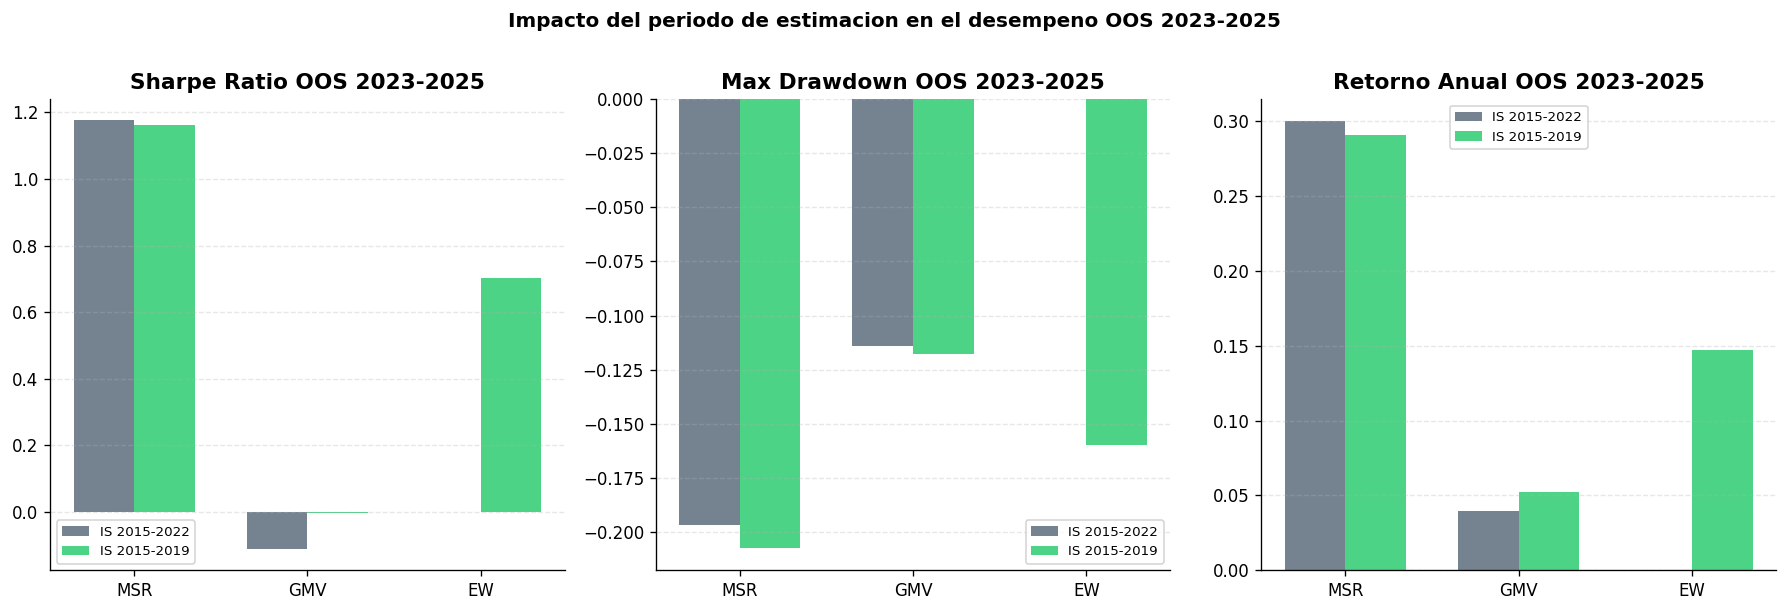

Comparativa guardada


In [15]:
if has_orig:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    metrics_cmp  = [
        ('sharpe',      'Sharpe Ratio OOS 2023-2025'),
        ('max_drawdown','Max Drawdown OOS 2023-2025'),
        ('ret_annual',  'Retorno Anual OOS 2023-2025'),
    ]
    labels_short = ['MSR', 'GMV', 'EW']
    porto_names  = ['Max Sharpe (MSR)', 'Min Varianza (GMV)', 'Igual Ponderacion (EW)']

    for ax, (metric, title) in zip(axes, metrics_cmp):
        x = np.arange(3)
        width = 0.35

        vals_orig = []
        for porto in porto_names:
            if porto in orig_oos.index and metric in orig_oos.columns:
                vals_orig.append(float(orig_oos.loc[porto, metric]))
            else:
                vals_orig.append(np.nan)

        vals_new = [float(new_oos_2023_df.loc[k, metric]) if k in new_oos_2023_df.index else np.nan
                    for k in labels_short]

        ax.bar(x - width/2, vals_orig, width, label='IS 2015-2022', color='#5D6D7E', alpha=0.85)
        ax.bar(x + width/2, vals_new,  width, label='IS 2015-2019', color='#2ECC71', alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels(labels_short)
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

    plt.suptitle('Impacto del periodo de estimacion en el desempeno OOS 2023-2025', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/comparativa_is_prepandemia_vs_full.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Comparativa guardada')
else:
    print('Ejecuta primero el notebook 03 para obtener la comparativa.')

---
## 9. Análisis de Sensibilidad

In [16]:
configs = [
    {'weight_bounds': (0.0, 0.15), 'shrinkage': True,  'label': 'max15_LW'},
    {'weight_bounds': (0.0, 0.25), 'shrinkage': True,  'label': 'max25_LW'},
    {'weight_bounds': (0.0, 0.30), 'shrinkage': True,  'label': 'max30_LW'},
    {'weight_bounds': (0.0, 0.25), 'shrinkage': False, 'label': 'max25_noLW'},
]

activos_full = [t for t in ALL_TICKERS if t in ret_oos.columns]
spy_full     = ret_oos[BENCHMARK] if BENCHMARK in ret_oos.columns else pd.Series(dtype=float)

sensitivity_rows = []
for cfg in configs:
    opt_tmp = MarkowitzOptimizer(
        prices       = prices,
        tickers      = ALL_TICKERS,
        train_end    = TRAIN_END,
        weight_bounds= cfg['weight_bounds'],
        shrinkage    = cfg['shrinkage'],
    )
    msr_tmp = opt_tmp.max_sharpe()
    r_tmp   = compute_portfolio_returns(msr_tmp.weights, ret_oos[activos_full])
    m       = full_metrics(r_tmp, spy_full, label=cfg['label'])
    m['config'] = cfg['label']
    sensitivity_rows.append(m)
    print(f"  {cfg['label']:20s}: Sharpe OOS={m['sharpe']:.3f} | MDD={m['max_drawdown']:.2%}")

sensitivity_df = pd.DataFrame(sensitivity_rows).set_index('config')
print('\n--- Analisis de sensibilidad: MSR OOS 2020-2025 ---')
print(sensitivity_df[['ret_annual','vol_annual','sharpe','sortino','max_drawdown','calmar']].round(4).to_string())

  max15_LW            : Sharpe OOS=0.699 | MDD=-33.82%
  max25_LW            : Sharpe OOS=0.697 | MDD=-37.41%
  max30_LW            : Sharpe OOS=0.685 | MDD=-37.74%
  max25_noLW          : Sharpe OOS=0.696 | MDD=-37.30%

--- Analisis de sensibilidad: MSR OOS 2020-2025 ---
            ret_annual  vol_annual  sharpe  sortino  max_drawdown  calmar
config                                                                   
max15_LW        0.2252      0.2472  0.6988   0.9012       -0.3382  0.6660
max25_LW        0.2359      0.2631  0.6969   0.9080       -0.3741  0.6305
max30_LW        0.2334      0.2641  0.6850   0.8929       -0.3774  0.6184
max25_noLW      0.2354      0.2627  0.6961   0.9065       -0.3730  0.6309


---
## 10. Persistencia de Resultados

In [17]:
for period, df in results_by_period.items():
    df.to_csv(f'{OUTPUT_DIR}/metrics_{period}.csv')

nav_df = pd.DataFrame({'MSR': nav_msr, 'GMV': nav_gmv, 'EW': nav_ew})
if nav_spy is not None:
    nav_df['SPY'] = nav_spy
nav_df.to_parquet(f'{OUTPUT_DIR}/nav_oos_prepandemia.parquet')

wt = opt.weights_table()
wt.to_csv(f'{OUTPUT_DIR}/pesos_prepandemia.csv')
frontier.to_csv(f'{OUTPUT_DIR}/frontera_eficiente_prepandemia.csv', index=False)
sensitivity_df.to_csv(f'{OUTPUT_DIR}/sensibilidad_prepandemia.csv')

print(f'Resultados guardados en: {OUTPUT_DIR}/')
for f in os.listdir(OUTPUT_DIR):
    print(f'  {f}')

Resultados guardados en: ../data/processed/markowitz_prepandemic/
  comparativa_is_prepandemia_vs_full.png
  crash_covid_zoom.png
  frontera_eficiente_prepandemia.csv
  frontera_eficiente_prepandemia.png
  heatmap_subperiodos_prepandemia.png
  metrics_Expansion_2023_25.csv
  metrics_OOS_Total_2020_25.csv
  metrics_Pandemia_2020.csv
  metrics_Recuperacion_2021_22.csv
  nav_oos_prepandemia.parquet
  nav_oos_prepandemia.png
  pesos_portafolios_prepandemia.png
  pesos_prepandemia.csv
  sensibilidad_prepandemia.csv


---
## 11. Conclusiones

### Hallazgos principales

| Observacion | Implicacion |
|-------------|-------------|
| Parametros estimados **sin** pandemia generan portafolios mas agresivos en IT/CD | El crash 2020 no estaba en el mapa del optimizador |
| El **GMV** resiste mejor el crash que el MSR | La restriccion de varianza minima actua como escudo en shocks |
| La recuperacion 2021-22 favorece portafolios concentrados en IT | Sesgo de momento que Markowitz no captura dinamicamente |
| Los parametros IS 2015-2019 **sobreestiman** el Sharpe esperado en 2020+ | El modelo asume distribucion estacionaria → falla en cambios de regimen |

### Limitaciones que motivan ML + CVaR

1. **Estacionariedad**: Markowitz supone retornos i.i.d. → no captura cambios de regimen
2. **Estimacion de media**: Los retornos esperados son muy ruidosos con ventanas cortas
3. **Covarianza estatica**: La correlacion se dispara en shocks, subestimando el riesgo real
4. **Sin senales predictivas**: No incorpora momentum, RSI, ni indicadores macro

> **Siguiente paso**: `06_supervised_learning.ipynb` — ML para prediccion de retornos y construccion dinamica del portafolio